In [1]:
# importando bibliotecas
import tensorflow as tf 
import keras
import matplotlib
import numpy as np

2026-02-23 14:42:53.373363: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-23 14:42:53.489168: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# verificando as versões
tf.__version__, keras.__version__, matplotlib.__version__, np.__version__

('2.16.1', '3.4.1', '3.7.1', '1.25.2')

In [3]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import InputLayer, Dense, Flatten, Dropout, Conv2D, MaxPooling2D,BatchNormalization
from keras import utils as np_utils
import matplotlib.pyplot as plt

In [4]:
# baixando os dados de treino e teste da biblioteca mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [5]:
# vendo a quantidade de imagens e os parametros
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

In [6]:
# calculando a quantidade de pixels no total da imagem
28*28

784

In [7]:
# vendo como são os dados de treinamento
X_train, X_train.max()

(array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        ...,
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],

In [8]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

Text(0.5, 1.0, 'Classe 5')

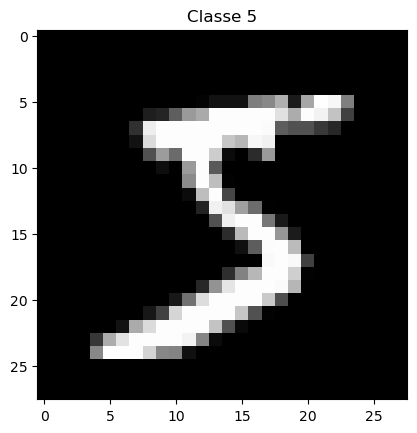

In [9]:
# mostrando a primeira imagem e sua resposta
plt.imshow(X_train[0], cmap='gray')
plt.title('Classe ' + str(y_train[0]))

In [10]:
# pré processamento (mostrar a quantidade de camadas que possui)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
X_train.shape, X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [11]:
# transformando em float
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [12]:
# normalizando os dados entre 0 e 1
X_train /=255
X_test /= 255

In [13]:
# verificando se deu certo
X_train.max(), X_train.min()

(1.0, 0.0)

In [14]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [15]:
# invés do valor em si, transformamos em uma array categorica (probabilidade de ser cada um dos valores)
y_train = np_utils.to_categorical(y_train, 10)
y_test = np_utils.to_categorical(y_test, 10)

In [16]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [25]:
# criando a rede neural
neural_network = Sequential() # rede neural
neural_network.add(InputLayer(shape=(28,28,1))) # camada de entrada, com 28 linhas e colunas, e apenas 1 camada de profundidade

neural_network.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu')) # 32 detectores de características, com tamanho 3x3. Função relu (valor negativo vira 0)
neural_network.add(BatchNormalization())
neural_network.add(MaxPooling2D(pool_size=(2,2))) # camada de pooling, seleciona matrizes de 2x2 para pegar o maior valor

# duplicando esse bloco de camadas
neural_network.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu')) # 32 detectores de características, com tamanho 3x3. Função relu (valor negativo vira 0)
neural_network.add(BatchNormalization())
neural_network.add(MaxPooling2D(pool_size=(2,2))) # camada de pooling, seleciona matrizes de 2x2 para pegar o maior valor

neural_network.add(Flatten()) # transforma em uma array

neural_network.add(Dense(units=128, activation='relu')) # camada densa
neural_network.add(Dropout(0.2)) # camada para evitar overfiting
neural_network.add(Dense(units=128, activation='relu')) # camada densa
neural_network.add(Dropout(0.2)) # camada para evitar overfiting
neural_network.add(Dense(units=10, activation='softmax')) # camada de saída

In [26]:
neural_network.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 11, 11, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,154 (508.41 KB)

 Trainable params: 130,026 (507.91 KB)

 Non-trainable params: 128 (512.00 B)

In [27]:
# comnpilação da rede neural
neural_network.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [28]:
# treinamento da rede neural
neural_network.fit(X_train, y_train, batch_size=128, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.8454 - loss: 0.4972 - val_accuracy: 0.9457 - val_loss: 0.1797
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.9803 - loss: 0.0687 - val_accuracy: 0.9852 - val_loss: 0.0478
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9855 - loss: 0.0470 - val_accuracy: 0.9869 - val_loss: 0.0434
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9885 - loss: 0.0375 - val_accuracy: 0.9883 - val_loss: 0.0379
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9912 - loss: 0.0277 - val_accuracy: 0.9897 - val_loss: 0.0346


In [29]:
# vendo os resultados
result = neural_network.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9844 - loss: 0.0489


In [30]:
# primeiro valor é o erro e o segundo é a accuracy
result

[0.03457676246762276, 0.9897000193595886]